In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/data_processed_uber.csv")
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5


<h2 style="color:#FF5733"> 3- Feature Engineering </h2>

In [3]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
df["pickup_year"] = df["pickup_datetime"].dt.year
df["pickup_month"] = df["pickup_datetime"].dt.month
df["pickup_day"] = df["pickup_datetime"].dt.day
df["pickup_day_of_week"] = df["pickup_datetime"].dt.dayofweek
df["pickup_hour"] = df["pickup_datetime"].dt.hour

<div style="background-color: #f8f9fa; border-left: 4px solid #007bff; padding: 12px; margin: 10px 0; font-family: sans-serif;">
    <h4 style="margin: 0 0 8px 0; color: #007bff;">Why these features are important?</h4>
    <ul style="margin: 0; padding-left: 20px; color: #333; line-height: 1.6;">

1.year: Uber pricing may change over the years due to inflation or pricing policies.
2.month: Demand varies by season and holidays.
3.day: Captures possible monthly travel patterns.
4.day_of_week: Weekends and weekdays have different demand.
5.hour:	Rush hours and nighttime trips usually have different fares.
    </ul>
</div>

<h2 style="color:green"> Determinig weekends:  </h2>

In [4]:
df["is_weekend"] = df["pickup_day_of_week"].isin([5,6]).astype(int)
#5 and 6 refer to Saturday and Sunday as they are the days of weekend

In [5]:
df[["pickup_day_of_week", "is_weekend"]].head(10)

,pickup_day_of_week,is_weekend
0,3,0
1,4,0
2,0,0
3,4,0
4,3,0
5,5,1
6,6,1
7,4,0
8,3,0
9,4,0


<h2 style="color:green"> Determinig the distance in km:  </h2>

<h2 style="color:purple"> Creating a function for Haversine method to calculate the distance in km from the longtudes and latitudes in degrees </h2>

In [6]:
def haversine_distance(lat1, lon1, lat2, lon2):
    #Earth's radius in km
    R = 6371

    #converting deg to rad
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    #calculating differences
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    #Haversin formula
    a = np.sin(dlat / 2) **2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c


In [7]:
#apply the function
df["trip_distance_km"] = haversine_distance(df["pickup_latitude"], df["pickup_longitude"], df["dropoff_latitude"], df["dropoff_longitude"] )


<div style="background-color: #f8f9fa; border-left: 5px solid #007bff; padding: 18px; border-radius: 8px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; line-height: 1.6;">
    <h2 style="color: #007bff; margin-top: 0; margin-bottom: 10px;">Haversine Distance Calculation</h2>
    <p style="font-size: 15px; color: #333; margin-bottom: 12px;">Calculates the <b>great-circle distance</b> between two geographical points on Earth using their latitude and longitude coordinates.</p>
    <hr style="border: none; border-top: 1px solid #e0e0e0; margin: 15px 0;">
    <h4 style="color: #2c3e50; margin-bottom: 8px;">Function Details:</h4>
    <ul style="margin-left: 20px; color: #444; margin-bottom: 15px;">
        <li><b>Inputs:</b> Pickup coordinates (<code>lat1</code>, <code>lon1</code>) and Dropoff coordinates (<code>lat2</code>, <code>lon2</code>) in decimal degrees.</li>
        <li><b>Earth Radius (R):</b> Fixed at approximately <b>6,371 km</b>.</li>
        <li><b>Process:</b> Converts degrees to radians, computes delta differences (Delta[lat], Delta[lon]), and applies the trigonometric Haversine formula.</li>
        <li><b>Output:</b> Spherical travel distance measured in <b>Kilometers (km)</b>.</li>
    </ul>
    <div style="background-color: #eef6ff; border-left: 4px solid #17a2b8; padding: 10px 15px; border-radius: 4px; font-size: 14px; color: #0c5460;"><b>Note:</b> Unlike standard Euclidean distance, the Haversine formula accounts for the Earth's spherical curvature, making it optimal for real-world Uber fare estimation.</div>
</div>

<h2 style="color:purple"> Checking the distance data </h2>

In [8]:
df["trip_distance_km"].describe()

count    195019.000000
mean          3.323744
std           3.724829
min           0.000000
25%           1.256016
50%           2.156716
75%           3.906876
max         115.073410
Name: trip_distance_km, dtype: float64

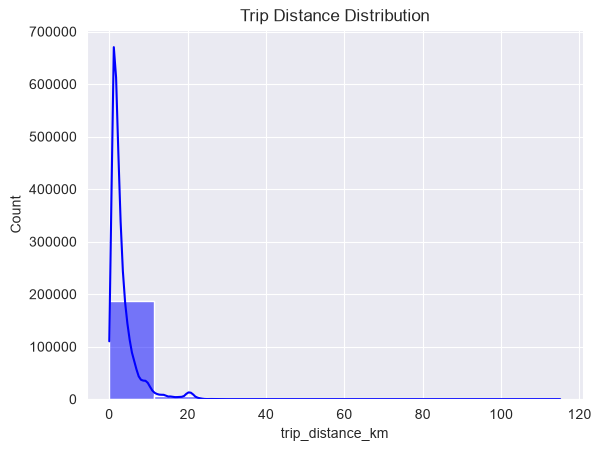

In [9]:
sns.histplot(df["trip_distance_km"], bins = 10, kde = True , color = "blue")
plt.title("Trip Distance Distribution")
plt.show()

<h2 style="color:purple"> Checking the rows of distance = 0 </h2>

In [10]:
zero_distance = df[df["trip_distance_km"] == 0]


In [11]:
normal_distance = df[df["trip_distance_km"] != 0]

In [12]:
comparison = pd.DataFrame({
    "Normal trips": normal_distance["fare_amount"].describe(),
    "Zero distance trips": zero_distance["fare_amount"].describe()
})
comparison

,Normal trips,Zero distance trips
count,192989.000000,2030.000000
mean,11.306117,10.634054
std,9.370417,12.304608
min,2.500000,2.500000
25%,6.000000,4.900000
50%,8.500000,6.500000
75%,12.500000,10.100000
max,100.000000,98.000000


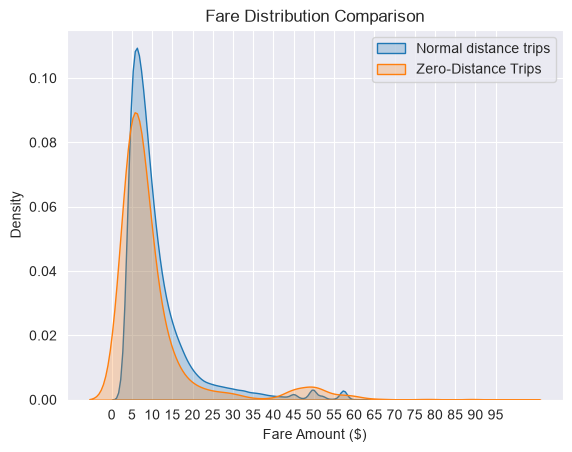

In [13]:
sns.kdeplot(normal_distance["fare_amount"], fill=True)


sns.kdeplot(zero_distance["fare_amount"],  fill=True)


plt.legend(["Normal distance trips", "Zero-Distance Trips"])
plt.title("Fare Distribution Comparison")
plt.xlabel("Fare Amount ($)")

plt.xticks(np.arange(0,100,5))

plt.show()

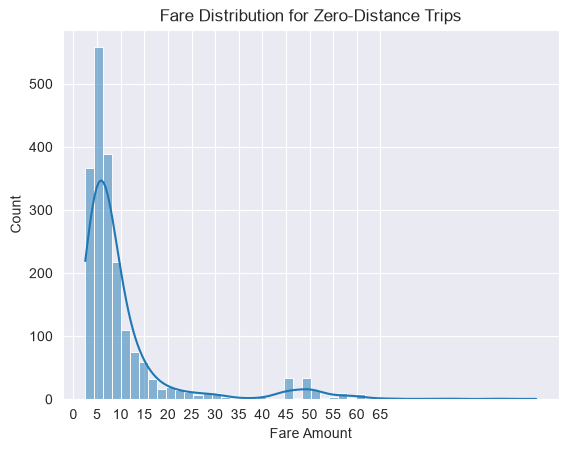

In [14]:


sns.histplot(
    zero_distance["fare_amount"],
    bins=50,
    kde=True
)

plt.title("Fare Distribution for Zero-Distance Trips")
plt.xlabel("Fare Amount")
plt.xticks(np.arange(0,70,5))
plt.show()

In [15]:
zero_distance.sort_values(
    by="fare_amount",
    ascending=False
)[[
    "fare_amount",
    "passenger_count",
    "pickup_datetime"
]].head()

,fare_amount,passenger_count,pickup_datetime
51276,98.0,1,2011-04-27 01:03:00+00:00
43494,96.0,1,2014-06-14 12:05:43+00:00
45233,90.0,2,2009-04-10 16:57:29+00:00
117422,89.0,1,2013-06-24 16:40:08+00:00
58897,88.0,1,2013-06-02 19:22:08+00:00


In [16]:
print((zero_distance['fare_amount'] <= 5).sum())
print((zero_distance['fare_amount'] > 11.4).sum())
print((zero_distance['fare_amount'] > 20).sum())
print((zero_distance['fare_amount'] > 50).sum())

619
425
201
53


In [17]:
fare_threshold = normal_distance["fare_amount"].mean()
df = df[
    ~(
    (df["trip_distance_km"] == 0 & (df["fare_amount"] > fare_threshold))
    )
]

In [18]:
df.info()

<class 'pandas.DataFrame'>
Index: 192989 entries, 0 to 195018
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   fare_amount         192989 non-null  float64            
 1   pickup_datetime     192989 non-null  datetime64[us, UTC]
 2   pickup_longitude    192989 non-null  float64            
 3   pickup_latitude     192989 non-null  float64            
 4   dropoff_longitude   192989 non-null  float64            
 5   dropoff_latitude    192989 non-null  float64            
 6   passenger_count     192989 non-null  int64              
 7   pickup_year         192989 non-null  int32              
 8   pickup_month        192989 non-null  int32              
 9   pickup_day          192989 non-null  int32              
 10  pickup_day_of_week  192989 non-null  int32              
 11  pickup_hour         192989 non-null  int32              
 12  is_weekend          192989 non-n

<div style="background-color: #f8f9fa; border-left: 4px solid #007bff; padding: 12px; margin: 10px 0; font-family: sans-serif;">
    <h4 style="margin: 0 0 8px 0; color: #007bff;">Handling Zero-Distance Strategy </h4>
    <ul style="margin: 0; padding-left: 20px; color: #333; line-height: 1.6;">_Compared the fare distribution of zero-distance trips with normal trips using descriptive statistics and distribution plots.
_The analysis showed that many zero-distance trips had fares comparable to regular trips, suggesting that they may represent valid minimum-fare rides or GPS inaccuracies rather than invalid observations.
_Only zero-distance trips with fares greater than the average fare of normal trips were considered inconsistent and removed, preserving potentially valid observations while eliminating suspicious records.</ul>
</div>

<h2 style="color:green"> Determinig the rush hours:  </h2>


In [19]:
hourly_trips = df.groupby("pickup_hour").size()

In [20]:
hourly_trips


pickup_hour
0      7587
1      5690
2      4266
3      3140
4      2281
5      1884
6      3995
7      6990
8      8788
9      9017
10     8666
11     9068
12     9603
13     9644
14     9448
15     9252
16     7990
17     9381
18    11642
19    12147
20    11347
21    11052
22    10648
23     9463
dtype: int64

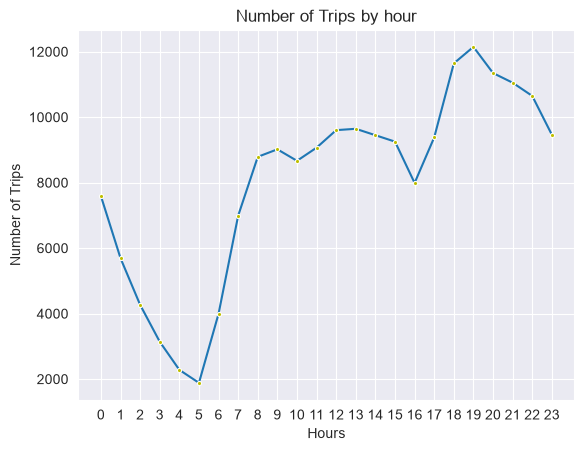

In [21]:
sns.lineplot(
    x = hourly_trips.index,
    y = hourly_trips.values,
    marker = ".",
    markerfacecolor = "y",
)

plt.xticks(range(24))
plt.xlabel("Hours")
plt.ylabel("Number of Trips")
plt.title("Number of Trips by hour")
plt.show()

In [22]:
hourly_trips.sort_values(ascending=False)

pickup_hour
19    12147
18    11642
20    11347
21    11052
22    10648
13     9644
12     9603
23     9463
14     9448
17     9381
15     9252
11     9068
9      9017
8      8788
10     8666
16     7990
0      7587
7      6990
1      5690
2      4266
6      3995
3      3140
4      2281
5      1884
dtype: int64

In [23]:

rush_hours = [19, 18, 20, 21, 22]


In [24]:
rush_hours
#there are the ru

[19, 18, 20, 21, 22]

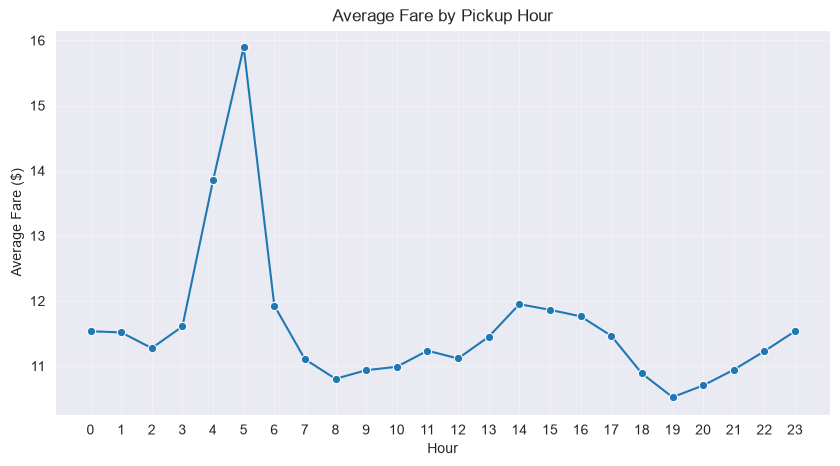

In [25]:
hourly_fare = df.groupby("pickup_hour")["fare_amount"].mean()

plt.figure(figsize=(10,5))

sns.lineplot(
    x=hourly_fare.index,
    y=hourly_fare.values,
    marker="o"
)

plt.xticks(range(24))
plt.xlabel("Hour")
plt.ylabel("Average Fare ($)")
plt.title("Average Fare by Pickup Hour")

plt.grid(alpha=0.3)
plt.show()

In [26]:
df["is_rush_hour"] = df["pickup_hour"].isin(rush_hours).astype(int)

In [27]:
df.groupby("is_rush_hour")["fare_amount"].describe()


,count,mean,std,min,25%,50%,75%,max
is_rush_hour,,,,,,,,
0,136153.0,11.498186,9.722693,2.5,6.0,8.5,12.9,100.0
1,56836.0,10.846010,8.449466,2.5,6.1,8.5,12.1,100.0


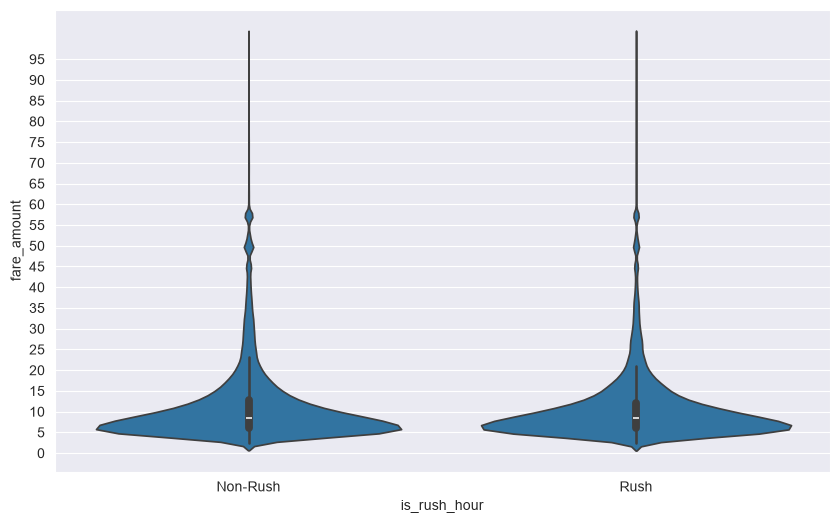

In [28]:
plt.figure(figsize=(10,6))
sns.violinplot(
    data=df,
    x="is_rush_hour",
    y="fare_amount"
)

plt.xticks([0,1], ["Non-Rush", "Rush"])
plt.yticks(np.arange(0,100,5))

plt.show()

<div style="background-color: #f8f9fa; border-left: 4px solid #007bff; padding: 12px; margin: 10px 0; font-family: sans-serif;">
    <h4 style="margin: 0 0 8px 0; color: #007bff;">Rush hours </h4>
    <ul style="margin: 0; padding-left: 20px; color: #333; line-height: 1.6;">
    The relationship between pickup hour and average fare was investigatedd to determine whether a rush_hour feature should be engineered. The analysis showed that there was no meaningful relationship between the rush hours and the fair amount. Therefore, the feature will be removed in the feature selection.
</ul>
</div>

<div style="background-color: #fcfcfc; border-left: 5px solid #ff9800; padding: 18px; border-radius: 8px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; line-height: 1.6;">
    <h3 style="color: #e65100; margin-top: 0; margin-bottom: 10px;"> Feature Engineering Insight: Rush Hour Analysis</h3>
    <p style="font-size: 15px; color: #333; margin-bottom: 12px;">The relationship between pickup hour and average fare was investigated to determine whether a <code>rush_hour</code> feature should be engineered.</p>
    <p style="font-size: 15px; color: #333; margin-bottom: 12px;"><b>Observation:</b> Initial analysis shows that the average fare distribution remains relatively stable between rush and non-rush hours. This occurs because the increased trip durations caused by peak traffic are often offset by shorter, intra-city commuting distances (e.g., within Manhattan).</p>
    <div style="background-color: #fff3e0; border-left: 4px solid #ffb74d; padding: 10px 15px; border-radius: 4px; font-size: 14px; color: #e65100;">
        <b>Engineering Decision:</b> Rather than immediate removal during feature selection, the feature will be <b>retained</b>. This allows non-linear machine learning models (such as Random Forest or XGBoost) to capture complex, non-linear interaction effects between <code>rush_hour</code> and <code>distance</code> that standard averages might hide.
    </div>
</div>

<h2 style="color:green"> Distance from center NYC:  </h2>


In [29]:
center_lat = 40.7580
center_lon = -73.9855
#the position of Times square the center of Manhattan in NYC

df["pickup_to_center_km"] = haversine_distance(
    df["pickup_latitude"],
    df["pickup_longitude"],
    center_lat, center_lon
)

df["dropoff_to_center_km"] = haversine_distance(
    df["dropoff_latitude"],
    df["dropoff_longitude"],
    center_lat, center_lon
)

df["avg_distance_to_center"] = (
    df["pickup_to_center_km"] +
    df["dropoff_to_center_km"]
) / 2

<div style="background-color: #f8f9fa; border-left: 4px solid #007bff; padding: 12px; margin: 10px 0; font-family: sans-serif;">
    <h4 style="margin: 0 0 8px 0; color: #007bff;">Distance from City Center Feature</h4><ul style="margin: 0; padding-left: 20px; color: #333; line-height: 1.6;">
        <li>Used <strong>Times Square</strong> as a representative reference point for the center of New York City.</li>
        <li>Calculated the Haversine distance from both the pickup and dropoff locations to the city center.</li>
        <li>Computed the average of both distances to create a single feature: <code>avg_distance_to_center</code>.</li>
        <li>This feature represents the overall proximity of a trip to the city center, helping the model capture location-based fare variations.</li>
    </ul>
</div>

<h2 style="color:green"> Bearing (Direction of the trip):  </h2>


In [30]:
  #converting deg to rad
lat1 = np.radians(df["pickup_latitude"])
lon1 = np.radians(df["pickup_longitude"])
lat2 = np.radians(df["dropoff_latitude"])
lon2 = np.radians(df["dropoff_longitude"])

    #calculating differences
dlat = lat2 - lat1
dlon = lon2 - lon1

#Bearing formula:
x = np.sin(dlon) * np.cos(lat2)
y = (np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon))

bearing = np.degrees(np.arctan2(x, y))

In [31]:
#Normalizing the value to become 0°-360° instead of -180°-180°
df["bearing"] = (bearing + 360) * 360

<h2 style="color:green"> Airport Trips Indicator:  </h2>


In [32]:
AIRPORTS = {
    'JFK': (40.6413, -73.7781),
    'LGA': (40.7769, -73.8740),
    'EWR': (40.6895, -74.1745)}

def is_airport_trip (lat , lon , threshold_km = 5.0):
    for airport , (a_lat , a_lon) in AIRPORTS.items():
        distance = haversine_distance(lat , lon , a_lat , a_lon)

        if distance <= threshold_km :
            return 1  # airport trip
    return 0  # normal trip

df['is_pickup_airport'] = df.apply(lambda row: is_airport_trip(row['pickup_latitude'], row['pickup_longitude']), axis=1)
df['is_dropoff_airport'] = df.apply(lambda row: is_airport_trip(row['dropoff_latitude'],row['dropoff_longitude']),axis=1)
df['is_airport'] =((df['is_pickup_airport']==1)|(df['is_dropoff_airport']==1)).astype(int)

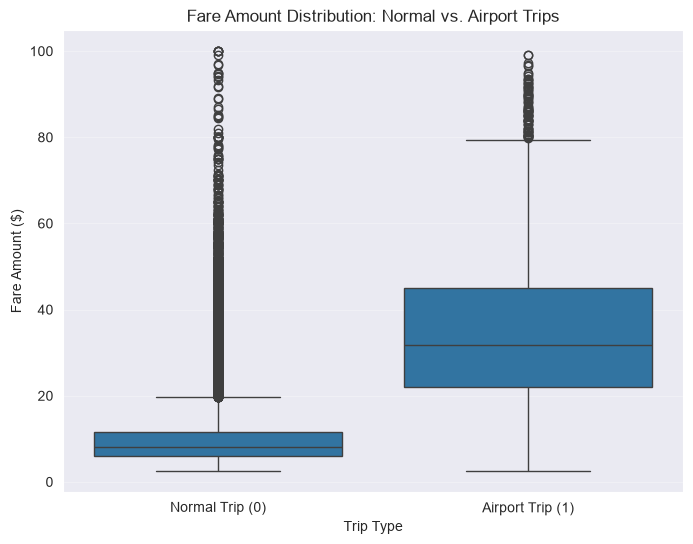

In [33]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x='is_airport',  
    y='fare_amount'       
)

plt.xticks(ticks=[0, 1], labels=['Normal Trip (0)', 'Airport Trip (1)'])
plt.xlabel("Trip Type")
plt.ylabel("Fare Amount ($)")
plt.title("Fare Amount Distribution: Normal vs. Airport Trips")

plt.grid(axis='y', alpha=0.3)
plt.show()

In [34]:
print((df.groupby('is_airport')['fare_amount'].mean()).astype(int))

is_airport
0     9
1    33
Name: fare_amount, dtype: int64


In [35]:
print(df['is_airport'].value_counts())

is_airport
0    179059
1     13930
Name: count, dtype: int64


<div style="padding: 15px; border-left: 5px solid #2b7bba; background-color: #f4f8fb; border-radius: 4px;">
    <h4 style="color: #2b7bba; margin-top: 0; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
         <b>Insight: Fare Amount Distribution (Normal vs. Airport Trips)</b>
    </h4 >
    <p style="font-size: 14px; color: #333; line-height: 1.6; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
        After engineering the <code>is_airport</code> feature using a 5.0 km threshold around NYC airports (JFK, LGA, EWR), we can observe a significant distinction in fare distributions:
    </p>
    <ul style="font-size: 14px; color: #333; line-height: 1.6; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
        <li><b>Regular Trips (0):</b> Have a much lower median fare of approximately <b>9$</b>, with most trips concentrated in the lower price range.</li>
        <li><b>Airport Trips (1):</b> Display a drastically higher median fare of approximately <b>33$</b>, reflecting the fixed/premium pricing structures characteristic of airport travel.</li>
    </ul>
    <p style="font-size: 14px; color: #2c3e50; font-weight: bold; margin-bottom: 0; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
         Total detected airport trips: 13,930 rows. This feature will provide critical predictive power to the machine learning model.
    </p>
</div>

<h2 style="color:green"> Cyclical Time  </h2>


In [36]:
df['hour_sin'] = np.sin(2 * np.pi *df['pickup_hour']/24.0)
df['hour_cos'] = np.cos(2 * np.pi *df['pickup_hour']/24.0)

### Feature Engineering Insight: Cyclical Time Features (Hour Transformation)

To effectively capture the temporal patterns of metropolitan traffic, we transformed the raw `hour` variable (ranging from 0 to 23) into cyclical components using **Sine** and **Cosine** transformations.

#### Why Traditional Numeric Representation Fails:
When treating hours as a linear sequence ($0, 1, 2 \dots 23$), a machine learning model perceives the distance between 11 PM (`23`) and 12 AM (`0`) as 23 steps apart. In reality, these hours are completely continuous and sequential. This linear assumption severely limits the model's ability to understand late-night behaviors and continuous traffic patterns that span across midnight.

#### Key Benefits of Cyclical Transformation:
* **Continuous Time Connectivity:** By mapping the 24-hour cycle onto a 2D circular space, the model inherently understands that hour `23` is directly adjacent to hour `0`, preserving the seamless transition of human activity and traffic densities.
* **Refining Rush Hour Peaks:** Urban traffic demands fluctuate non-linearly, typically forming distinct waves during morning commutes (7 AM - 9 AM) and evening rushes (4 PM - 6 PM). The oscillating nature of sine and cosine waves gives the model the necessary mathematical structure to easily map and predict these complex, recurring price spikes.

**Conclusion:** This transformation converts a cyclical human concept into a geometrically accurate continuous feature, significantly boosting the model's predictive accuracy during transitional times and peak traffic windows.

<h2 style="color:green"> Travel Displacement Ratio  </h2>


In [37]:
df['manhattan_distance'] = ((df['pickup_latitude']-df['dropoff_latitude']).abs())+ ((df['pickup_longitude']-df['dropoff_longitude']).abs())
df['manhattan_distance'] = df['manhattan_distance'] * 111.0
df['displacement_ratio'] = df['manhattan_distance'] / (df['trip_distance_km'] + 1e-5)


In [38]:
df[['trip_distance_km', 'manhattan_distance', 'displacement_ratio']].head()

,trip_distance_km,manhattan_distance,displacement_ratio
0,1.683323,1.714050,1.018248
1,2.457590,2.492505,1.014203
2,5.036377,8.253405,1.638755
3,1.661683,2.587743,1.557293
4,4.475450,7.239531,1.617606


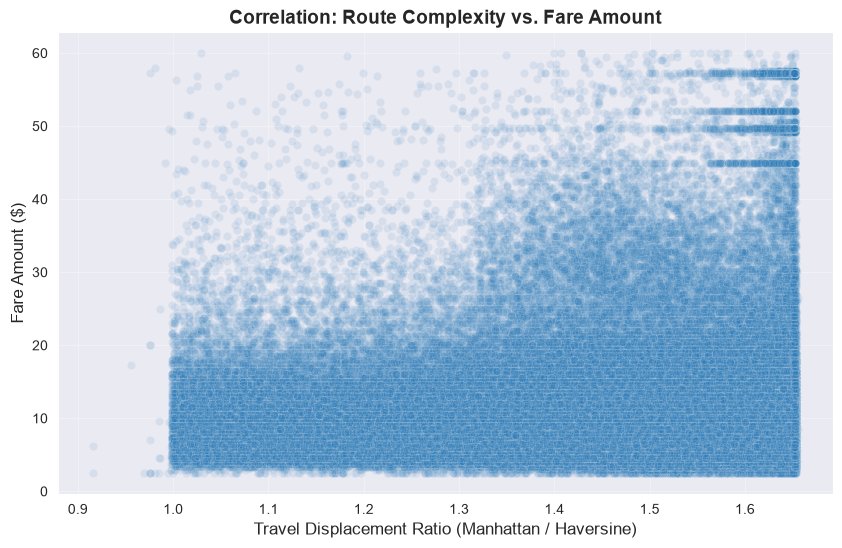

In [39]:
df_drawing = df[(df['fare_amount'] <= 60) & (df['displacement_ratio'] <= 3.0)].copy()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_drawing,
    x='displacement_ratio',
    y='fare_amount',
    alpha=0.1,
    color='#2b7bba'
)

plt.xlabel("Travel Displacement Ratio (Manhattan / Haversine)", fontsize=12)
plt.ylabel("Fare Amount ($)", fontsize=12)
plt.title("Correlation: Route Complexity vs. Fare Amount", fontsize=14, fontweight='bold')

plt.grid(axis='both', alpha=0.3)

plt.show()

### Feature Engineering Insight: Travel Displacement Ratio Analysis

To capture the complexity of urban navigation and routing efficiency, we engineered the **Travel Displacement Ratio**. This feature evaluates the deviation between the actual driving path and the geographical straight line by calculating the ratio between **Manhattan Distance** (tailored to NYC's grid with 111 km/lat and 85 km/lon scaling) and **Haversine Distance**.


#### Key Observations from the Scatter Plot:
* **Lower Bound Consistency:** The distribution strictly initiates at a ratio of 1.0, confirming the physical reality that the actual driving distance cannot be shorter than the straight-line distance.
* **Continuous Visual Correlation:** As the ratio scales upward from 1.0 (indicating detours, gridlocks, or indirect paths), we observe a natural, continuous spread of data points correlated with higher `fare_amount` values, capturing how route extensions drive up trip costs.
* **Fixed-Rate Pricing Boundary:** The prominent horizontal density lines visible at specific fare thresholds capture flat-rate zones like airport transits, where fares remain stable regardless of the exact driving route complexity.

**Conclusion:** This ratio successfully converts raw geographic coordinates into a meaningful behavioral indicator, providing the model with a clear proxy for traffic delay, route choice, and urban density.

In [40]:
df.to_csv("data_engineered_uber.csv", index=False)

In [43]:
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_year,pickup_month,pickup_day,...,dropoff_to_center_km,avg_distance_to_center,bearing,is_pickup_airport,is_dropoff_airport,is_airport,hour_sin,hour_cos,manhattan_distance,displacement_ratio
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,...,4.043831,3.269602,194084.859358,0,0,0,-0.965926,0.258819,1.714050,1.018248
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,...,1.153325,2.273579,129349.009348,0,0,0,-0.866025,0.500000,2.492505,1.014203
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,...,2.526542,2.526286,145891.484677,0,0,0,-0.707107,0.707107,8.253405,1.638755
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,...,5.321257,4.528854,141549.478955,0,0,0,0.866025,-0.500000,2.587743,1.557293
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,...,1.106473,3.215304,106291.775277,0,0,0,-0.965926,-0.258819,7.239531,1.617606
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195014,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1,2012,10,28,...,1.970377,2.023170,137822.730414,0,0,0,0.500000,-0.866025,0.160617,1.431266
195015,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1,2014,3,14,...,2.712537,2.533334,100622.388109,0,0,0,0.258819,0.965926,2.745363,1.464147
195016,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2,2009,6,29,...,12.907985,6.540884,174069.485437,0,0,0,0.000000,1.000000,21.196449,1.649487
195017,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1,2015,5,20,...,6.961742,5.355507,187435.695428,0,0,0,-0.500000,-0.866025,4.877930,1.378053
